In [1]:
from __future__ import annotations

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW_DIR = Path(
    r"C:\Users\firep\Downloads\simple_analysis_script\simple_analysis_script\sipm"
)

DEVICE = "hcsipm"        # "hcsipm" or "sipm"
EVENT = 0                # event number, zero-padded to 5 digits in the filename
ALIGN = False            # True subtracts the fixed channel offsets
SAVE_PNG = None          # e.g. Path("event_00000.png")

CHANNELS = ("C1", "C2", "C3", "C4")
COLORS = {"C1": "#1f77b4", "C2": "#d62728", "C3": "#2ca02c", "C4": "#9467bd"}

BASELINE_START_NS, BASELINE_END_NS = -50.0, -5.0
SEARCH_START_NS, SEARCH_END_NS = -20.0, 20.0
ZOOM_START_NS, ZOOM_END_NS = -8.0, 12.0

# Median offsets vs C1 in ns, measured from the v1 results. Replace with the
# values in channel_offsets.csv once timing_characterization_v2 has been run.
CHANNEL_OFFSETS_NS = {"C1": 0.0, "C2": 0.249, "C3": 0.127, "C4": 0.060}

In [2]:
def robust_sigma(values) -> float:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return math.nan
    return float(1.4826 * np.median(np.abs(values - np.median(values))))


def load_trace(path: Path):
    """Return (time_ns, pulse_v, amplitude_v, t_cfd50_ns, snr, t_global_peak_ns)."""
    frame = pd.read_csv(path, header=4, usecols=["Time", "Ampl"])
    frame = frame.apply(pd.to_numeric, errors="coerce").dropna()
    time_ns = frame["Time"].to_numpy(float) * 1e9
    ampl_v = frame["Ampl"].to_numpy(float)
    order = np.argsort(time_ns)
    time_ns, ampl_v = time_ns[order], ampl_v[order]

    base_mask = (time_ns >= BASELINE_START_NS) & (time_ns <= BASELINE_END_NS)
    baseline = float(np.median(ampl_v[base_mask])) if base_mask.any() else 0.0
    noise = robust_sigma(ampl_v[base_mask]) if base_mask.any() else math.nan
    centered = ampl_v - baseline

    # Bounded search: polarity and peak are found only near the trigger.
    win = (time_ns >= SEARCH_START_NS) & (time_ns <= SEARCH_END_NS)
    window_v = centered[win]
    polarity = 1 if np.max(window_v) >= -np.min(window_v) else -1
    pulse_v = polarity * centered

    start = int(np.flatnonzero(win)[0])
    peak = start + int(np.argmax(pulse_v[win]))
    amplitude = float(pulse_v[peak])

    # CFD 50% on the rising edge, crossing nearest the peak.
    level = 0.5 * amplitude
    segment = pulse_v[start : peak + 1]
    hits = np.flatnonzero((segment[:-1] < level) & (segment[1:] >= level))
    if hits.size:
        index = start + int(hits[-1])
        y0, y1 = pulse_v[index], pulse_v[index + 1]
        t0, t1 = time_ns[index], time_ns[index + 1]
        t_cfd = t0 if y1 == y0 else t0 + (level - y0) * (t1 - t0) / (y1 - y0)
    else:
        t_cfd = math.nan

    snr = amplitude / noise if noise and np.isfinite(noise) else math.nan
    t_global_peak = float(time_ns[int(np.argmax(pulse_v))])
    return time_ns, pulse_v, amplitude, t_cfd, snr, t_global_peak

In [3]:
traces = {}
for channel in CHANNELS:
    path = RAW_DIR / f"{channel}--{DEVICE}--{EVENT:05d}.csv"
    if not path.is_file():
        raise FileNotFoundError(path)
    traces[channel] = load_trace(path)

times = [row[3] for row in traces.values() if np.isfinite(row[3])]
spread_ns = max(times) - min(times) if len(times) > 1 else math.nan

print(f"{DEVICE} event {EVENT:05d}")
for channel, (_, _, amplitude, t_cfd, snr, t_global) in traces.items():
    shift = CHANNEL_OFFSETS_NS[channel] if ALIGN else 0.0
    flag = "  <- larger pulse outside window" if abs(t_global - t_cfd) > 20 else ""
    print(f"  {channel}: amp {amplitude * 1e3:6.1f} mV   SNR {snr:5.1f}   "
          f"CFD50 {t_cfd - shift:+8.3f} ns{flag}")
print(f"  four-channel spread: {spread_ns * 1e3:.0f} ps"
      f"{' (offsets removed)' if ALIGN else ''}")

hcsipm event 00000
  C1: amp   72.9 mV   SNR  48.8   CFD50   -1.904 ns
  C2: amp   89.9 mV   SNR  49.3   CFD50   -1.158 ns
  C3: amp   71.3 mV   SNR  47.8   CFD50   -1.719 ns
  C4: amp   94.7 mV   SNR   6.0   CFD50   -1.959 ns
  four-channel spread: 801 ps


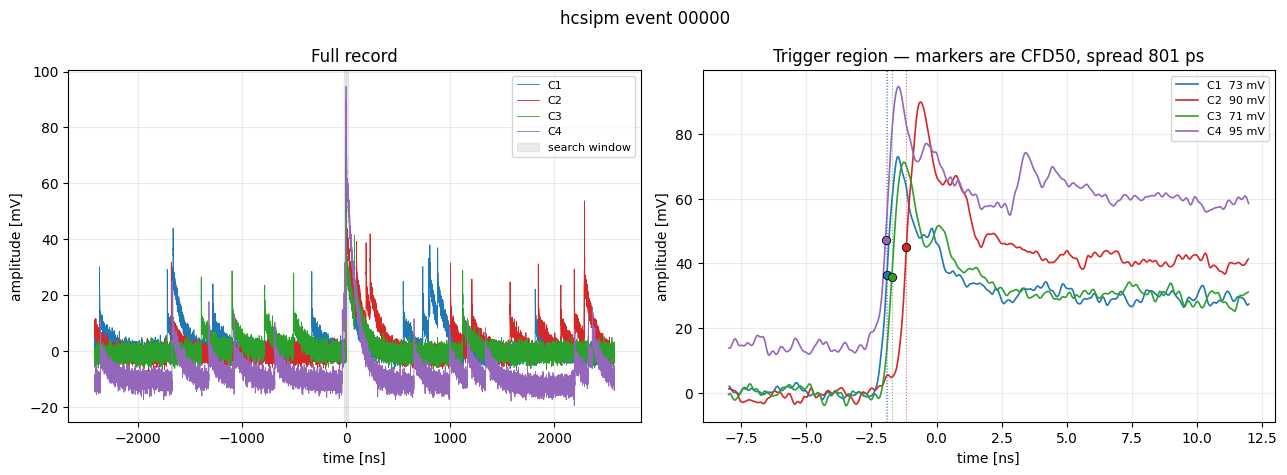

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

for channel, (time_ns, pulse_v, amplitude, t_cfd, _, _) in traces.items():
    shift = CHANNEL_OFFSETS_NS[channel] if ALIGN else 0.0
    color = COLORS[channel]

    axes[0].plot(time_ns - shift, pulse_v * 1e3, lw=0.6, color=color, label=channel)

    zoom = (time_ns >= ZOOM_START_NS + shift) & (time_ns <= ZOOM_END_NS + shift)
    axes[1].plot(time_ns[zoom] - shift, pulse_v[zoom] * 1e3, lw=1.2, color=color,
                 label=f"{channel}  {amplitude * 1e3:.0f} mV")
    if np.isfinite(t_cfd):
        axes[1].plot(t_cfd - shift, 0.5 * amplitude * 1e3, "o", color=color, ms=6,
                     mec="black", mew=0.6, zorder=5)
        axes[1].axvline(t_cfd - shift, color=color, ls=":", lw=0.8, alpha=0.7)

axes[0].axvspan(SEARCH_START_NS, SEARCH_END_NS, color="grey", alpha=0.15,
                label="search window")
axes[0].set_title("Full record")
axes[1].set_title(f"Trigger region — markers are CFD50, spread {spread_ns * 1e3:.0f} ps")

for axis in axes:
    axis.set_xlabel("time [ns]")
    axis.set_ylabel("amplitude [mV]")
    axis.grid(True, alpha=0.25)
    axis.legend(fontsize=8)

figure.suptitle(
    f"{DEVICE} event {EVENT:05d}" + (" (channel offsets removed)" if ALIGN else "")
)
figure.tight_layout()

if SAVE_PNG:
    figure.savefig(SAVE_PNG, dpi=160)
    print(f"saved -> {SAVE_PNG}")

plt.show()

In [5]:
EVENT_LIST = range(0, 6)

rows = []
for event in EVENT_LIST:
    for channel in CHANNELS:
        path = RAW_DIR / f"{channel}--{DEVICE}--{event:05d}.csv"
        if not path.is_file():
            continue
        _, _, amplitude, t_cfd, snr, t_global = load_trace(path)
        rows.append(
            {
                "event": event,
                "channel": channel,
                "amplitude_mV": amplitude * 1e3,
                "snr": snr,
                "cfd50_ns": t_cfd,
                "global_peak_ns": t_global,
                "peak_outside_window": abs(t_global - t_cfd) > 20,
            }
        )

scan = pd.DataFrame(rows)
if not scan.empty:
    pivot = scan.pivot(index="event", columns="channel", values="cfd50_ns")
    pivot["spread_ps"] = (pivot.max(axis=1) - pivot.min(axis=1)) * 1e3
    print(scan.to_string(index=False))
    print()
    print(pivot.to_string())

 event channel  amplitude_mV       snr  cfd50_ns  global_peak_ns  peak_outside_window
     0      C1     72.927585 48.769322 -1.904387       -1.461387                False
     0      C2     89.895477 49.330397 -1.157521       -0.628387                False
     0      C3     71.302790 47.836668 -1.719330       -1.235387                False
     0      C4     94.714525  6.049894 -1.958538       -1.467387                False
     1      C1     88.319395 35.666863 -1.445289       -1.042407                False
     1      C2    133.307705 85.835484 -1.129744       -0.659407                False
     1      C3     72.123360 41.095837 -1.232721       -0.766407                False
     1      C4     86.263210 36.839373 -1.286993       -0.698407                False
     2      C1     68.520230 46.723445 -1.825837       -1.254120                False
     2      C2     90.998195 62.875449 -1.723805       -1.221120                False
     2      C3     63.551800 35.916664 -1.590320      